#### Embeddings - представление слов в виде вектора чисел, отражающее смысл

king - man + woman = queen

paris - france + italy = rome


In [1]:
from unittest import result

import gensim # Библиотека для работы с  Word2Vec, Doc2Vec и с другими моделями
import numpy as np
from gensim import downloader as api
from gensim.models import Word2Vec

import numpy as np

import matplotlib.pyplot as plt
from pyexpat import model

from  sklearn.manifold import TSNE

print(gensim.__version__)

4.4.0


## 1. Word Embeddings

#### Word Embeddings

In [2]:
vocab = ["кот", "собака", "птица", "рыба", "слон"]

print("One Hot encoding:")

print("-"*50)

for i, word in enumerate(vocab):
    one_hot = np.zeros(len(vocab), dtype=int)
    one_hot[i] = 1
    print(f"{word:10} = {one_hot}")

print("-")
print("Dense embedings:")
print("-"*50)

embeddings = {
    "кот": np.array([0.8, 0.2, -0.1, 0.5]), # Домашние животные
    "собака": np.array([0.7, 0.3, -0.2, 0.5]), # похожи
    "птица": np.array([0.1, 0.9, 0.8, -0.1]), # летающие - другие
    "рыба": np.array([-0.5, 0.1, 0.3, 0.9]), # водные - совсем другие
    "слон": np.array([0.6, 0.4, -0.3, 0.4]), # крупное животное
}

for word, vec in embeddings.items():
    print(f"{word:10} = {vec}")


One Hot encoding:
--------------------------------------------------
кот        = [1 0 0 0 0]
собака     = [0 1 0 0 0]
птица      = [0 0 1 0 0]
рыба       = [0 0 0 1 0]
слон       = [0 0 0 0 1]
-
Dense embedings:
--------------------------------------------------
кот        = [ 0.8  0.2 -0.1  0.5]
собака     = [ 0.7  0.3 -0.2  0.5]
птица      = [ 0.1  0.9  0.8 -0.1]
рыба       = [-0.5  0.1  0.3  0.9]
слон       = [ 0.6  0.4 -0.3  0.4]


In [3]:
# Вычисление косинусного сходства между векторами
def cosine_similarity(vec1, vec2):
    """
        cos(θ) = (A · B) / (||A|| × ||B||)
    """
    dot_product = np.dot(vec1, vec2)

    norm1 = np.linalg.norm(vec1) # ||A|| = sqrt(a1² + a2² + ...)
    norm2 = np.linalg.norm(vec2) # ||A|| = sqrt(a1² + a2² + ...)

    return dot_product / (norm1 * norm2)

print("Cosine similarity:")
print("-"*50)

words = list(embeddings.keys())
for i in range(len(words)):
    for j in range(i+1, len(words)):
        word1, word2 = words[i], words[j]
        sim = cosine_similarity(embeddings[word1], embeddings[word2])
        print(f"{word1:10} - {word2:10} = {sim}")

Cosine similarity:
--------------------------------------------------
кот        - собака     = 0.9841616856627443
кот        - птица      = 0.11059124777543396
кот        - рыба       = 0.03830602342540456
кот        - слон       = 0.9285767423913251
собака     - птица      = 0.1149542569667464
собака     - рыба       = 0.06968020490219626
собака     - слон       = 0.9774284999977502
птица      - рыба       = 0.14550098687084356
птица      - слон       = 0.13159033899195383
рыба       - слон       = 0.010580973892262188


## 2. Word2Vec: Обучение собственной модели

In [4]:
corpus = [
    ["кот", "сидит", "на", "диване", "и", "спит"],
    ["собака", "лежит", "на", "ковре", "и", "отдыхает"],
    ["кот", "ловит", "мышь", "в", "саду"],
    ["собака", "бегает", "по", "улице"],
    ["птица", "летит", "в", "небе"],
    ["рыба", "плавает", "в", "воде"],
    ["кот", "и", "собака", "играют", "вместе"],
    ["птица", "сидит", "на", "дереве"],
    ["рыба", "живёт", "в", "аквариуме"],
    ["собака", "охраняет", "дом"],
    ["кот", "мурлычет", "от", "удовольствия"],
    ["большая", "собака", "лает", "громко"],
    ["маленький", "кот", "спит", "в", "корзине"],
    ["красивая", "птица", "поёт", "песню"],
    ["золотая", "рыба", "плавает", "в", "пруду"]
]

print(f"{len(corpus)} sentences in corpus")
print(f"Sentences example: {corpus[0]}")

all_words = set()
for sentence in corpus:
    all_words.update(sentence)
print(f"{len(all_words)} unique words in corpus")


15 sentences in corpus
Sentences example: ['кот', 'сидит', 'на', 'диване', 'и', 'спит']
43 unique words in corpus


In [5]:
model = Word2Vec(
    sentences=corpus,
    vector_size=50,
    window=5,
    min_count=1,
    workers=4,
    epochs=100,
    sg=1, # 1 Skip-gram (контекст по слову), 0 = CBOW(слова по контексту)
)

print(len(model.wv))
print(model.wv.vector_size)
print(list(model.wv.key_to_index.keys()))

43
50
['в', 'собака', 'кот', 'рыба', 'птица', 'и', 'на', 'плавает', 'спит', 'сидит', 'пруду', 'золотая', 'песню', 'поёт', 'красивая', 'корзине', 'маленький', 'громко', 'лает', 'большая', 'удовольствия', 'от', 'мурлычет', 'дом', 'охраняет', 'аквариуме', 'живёт', 'дереве', 'вместе', 'играют', 'воде', 'небе', 'летит', 'улице', 'по', 'бегает', 'саду', 'мышь', 'ловит', 'отдыхает', 'ковре', 'лежит', 'диване']


In [6]:
cat_vector = model.wv["кот"]
print(cat_vector[:10])

dog_vector = model.wv["собака"]
print(dog_vector[:10])

[-0.01776348  0.00801032  0.01071676  0.0117433   0.01494474 -0.01335139
  0.00344423  0.01468321 -0.00647001 -0.01393805]
[-0.0169459   0.00981907 -0.00802178  0.00175042  0.01703472 -0.00965092
  0.010006   -0.0120267  -0.0079057   0.01758802]


In [7]:
similar_to_cat = model.wv.most_similar("кот", topn=5)

for word, similarity in similar_to_cat:
    print(f"{word:15} - {similarity:.4f}")

print("-"*50)

similar_to_dog = model.wv.most_similar("собака", topn=5)

for word, similarity in similar_to_dog:
    print(f"{word:15} - {similarity:.4f}")

саду            - 0.2637
бегает          - 0.2616
птица           - 0.2182
в               - 0.2158
лает            - 0.2130
--------------------------------------------------
воде            - 0.3800
вместе          - 0.2499
маленький       - 0.2377
аквариуме       - 0.2337
улице           - 0.1917


In [8]:
similar_cat_dog = model.wv.similarity("кот", "собака")
print(f"Similarity words: {similar_cat_dog:4f}")

similar_cat_fish = model.wv.similarity("кот", "рыба")
print(f"Similarity words: {similar_cat_fish:4f}")

similar_bird_fly = model.wv.similarity("птица", "летит")
print(f"Similarity words: {similar_bird_fly:4f}")


similar_fish_swim = model.wv.similarity("рыба", "плавает")
print(f"Similarity words: {similar_fish_swim:4f}")


Similarity words: 0.066631
Similarity words: -0.131792
Similarity words: -0.086428
Similarity words: 0.058461


In [10]:
# Арифметика с векторами слов
print("Арифметика с векторами")
print("*"*40)
try:
    result = model.wv.most_similar(
        positive=["рыба", "сидит"], # рыба + сидит
        negative=['плавает'],
        topn=3
    )
    print("рыба + сидит - плавает")
    for word, similarity in result:
        print(f"{word:15} - {similarity:.4f}")
except KeyError as e:
    print("Слово не найдено")


Арифметика с векторами
****************************************
рыба + сидит - плавает
диване          - 0.3445
небе            - 0.2953
улице           - 0.2000


## 3. Использование предобученных моделей

In [12]:
available_models = api.info()["models"]

for name, info in list(available_models.items())[:10]:
    size_mb = info.get("file_size", 0) / (1024*1024)
    print(f"name: {name}, size: {size_mb:.1f} MB")

name: fasttext-wiki-news-subwords-300, size: 958.4 MB
name: conceptnet-numberbatch-17-06-300, size: 1168.7 MB
name: word2vec-ruscorpora-300, size: 198.8 MB
name: word2vec-google-news-300, size: 1662.8 MB
name: glove-wiki-gigaword-50, size: 66.0 MB
name: glove-wiki-gigaword-100, size: 128.1 MB
name: glove-wiki-gigaword-200, size: 252.1 MB
name: glove-wiki-gigaword-300, size: 376.1 MB
name: glove-twitter-25, size: 104.8 MB
name: glove-twitter-50, size: 199.5 MB


In [13]:
print("-"*40)
print("GloVe-Twitter-25")

glove_model = api.load("glove-twitter-25")
print("Dictionary length:", len(glove_model))
print("Vectors size:", glove_model.vector_size)

----------------------------------------
GloVe-Twitter-25
[==================================================] 100.0% 104.8/104.8MB downloaded
Dictionary length: 1193514
Vectors size: 25


In [29]:
print("'king' similarity words")
print('-'*40)

for word, similarity in glove_model.most_similar("king", topn=5):
    print(f"{word:15} - {similarity:.4f}")

print("'computer' similarity words")
print('-'*40)

for word, similarity in glove_model.most_similar("computer", topn=5):
    print(f"{word:15} - {similarity:.4f}")

print("'intelligence' similarity words")
print('-'*40)

for word, similarity in glove_model.most_similar("intelligence", topn=5):
    print(f"{word:15} - {similarity:.4f}")

'king' similarity words
----------------------------------------
prince          - 0.9337
queen           - 0.9202
aka             - 0.9177
lady            - 0.9163
jack            - 0.9147
'computer' similarity words
----------------------------------------
camera          - 0.9078
cell            - 0.8919
server          - 0.8745
device          - 0.8694
wifi            - 0.8631
'intelligence' similarity words
----------------------------------------
influence       - 0.9080
identity        - 0.9020
communication   - 0.8961
values          - 0.8893
authority       - 0.8859


In [38]:
result = glove_model.most_similar(
    positive=["king","woman"],
    negative=["man"],
    topn=5
)
for word, similarity in result:
    print(f"{word:15} - {similarity:.4f}")
print("-"*40)
result = glove_model.most_similar(
    positive=["paris","azerbaijan"],
    negative=["france"],
    topn=5
)
for word, similarity in result:
    print(f"{word:15} - {similarity:.4f}")

print("-"*40)
result = glove_model.most_similar(
    positive=["fast", "bad"],
    negative=["slow"],
    topn=5
)
for word, similarity in result:
    print(f"{word:15} - {similarity:.4f}")

meets           - 0.8842
prince          - 0.8322
queen           - 0.8257
’s              - 0.8174
crow            - 0.8135
----------------------------------------
belarus         - 0.8630
bulgaria        - 0.8607
slovakia        - 0.8538
kazakhstan      - 0.8532
magalona        - 0.8434
----------------------------------------
yet             - 0.8893
also            - 0.8888
made            - 0.8791
'd              - 0.8772
want            - 0.8768


In [39]:
word_lists = [
    ["breakfast", "lunch", "dinner", "car"],       # car - не еда
    ["cat", "dog", "bird", "table"],               # table - не животное
    ["red", "green", "blue", "happy"],             # happy - не цвет
    ["monday", "tuesday", "friday", "summer"]      # summer - не день недели
]

for words in word_lists:
    try:
        # doesnt_match находит слово, которое наименее похоже на остальные
        odd_one = glove_model.doesnt_match(words)
        print(f"Слова: {words}")
        print(f"Лишнее слово: {odd_one}")
        print()
    except KeyError as e:
        print(f"Ошибка: {e}")

Слова: ['breakfast', 'lunch', 'dinner', 'car']
Лишнее слово: car

Слова: ['cat', 'dog', 'bird', 'table']
Лишнее слово: table

Слова: ['red', 'green', 'blue', 'happy']
Лишнее слово: happy

Слова: ['monday', 'tuesday', 'friday', 'summer']
Лишнее слово: summer



In [40]:
# Визуализация векторов слов с помощью t-SNE

# Выбираем слова для визуализации (группы связанных слов)
words_to_visualize = [
    # Животные
    "cat", "dog", "bird", "fish", "horse",
    # Страны
    "russia", "france", "germany", "japan", "china",
    # Цвета
    "red", "blue", "green", "yellow", "black",
    # Еда
    "pizza", "burger", "sushi", "pasta", "rice"
]

# Фильтруем только слова, которые есть в модели
words_in_model = [w for w in words_to_visualize if w in glove_model]

# Получаем векторы для этих слов
vectors = np.array([glove_model[word] for word in words_in_model])

print(f"Слов для визуализации: {len(words_in_model)}")
print(f"Размерность векторов: {vectors.shape}")


Слов для визуализации: 20
Размерность векторов: (20, 25)


Размерность после t-SNE: (20, 2)


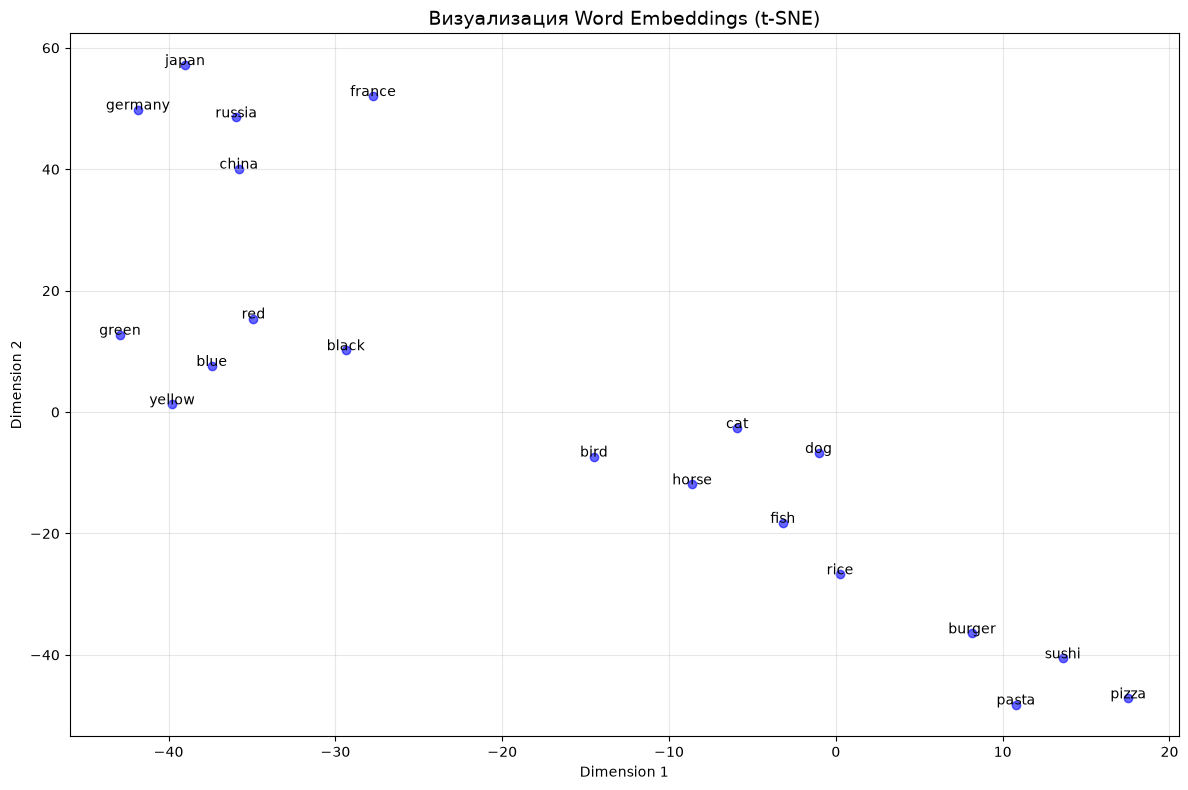


Схожие слова должны располагаться близко друг к другу на графике!


In [41]:
# Применяем t-SNE для уменьшения размерности до 2D

# t-SNE преобразует многомерные векторы в 2D, сохраняя относительные расстояния
tsne = TSNE(
    n_components=2,    # Уменьшаем до 2 измерений
    random_state=42,   # Для воспроизводимости
    perplexity=5       # Параметр t-SNE (для маленьких датасетов нужно меньше)
)

# Преобразуем векторы
vectors_2d = tsne.fit_transform(vectors)

print(f"Размерность после t-SNE: {vectors_2d.shape}")

# Создаём визуализацию
plt.figure(figsize=(12, 8))

# Рисуем точки
plt.scatter(vectors_2d[:, 0], vectors_2d[:, 1], c='blue', alpha=0.6)

# Добавляем подписи к точкам
for i, word in enumerate(words_in_model):
    plt.annotate(
        word,                          # Текст подписи
        xy=(vectors_2d[i, 0], vectors_2d[i, 1]),  # Координаты точки
        fontsize=10,
        ha='center'
    )

plt.title("Визуализация Word Embeddings (t-SNE)", fontsize=14)
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nСхожие слова должны располагаться близко друг к другу на графике!")